In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.95'
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')

%load_ext autoreload
%autoreload 2


/tmp/ipykernel_2842276/940688415.py:5: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


/projects/bdne/spandey3/envs/charm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
deproj = 'cib_1p7_dBeta'
# deproj = 'cib_1p7'
probe = 'all'
# smooth_mm_model = 'response'
# smooth_ym_model = 'response'

smooth_mm_model = 'power_add'
smooth_ym_model = 'power_add'


cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.783, 'ns': 0.95, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.95, 'w0':-1.0}
sim_params_dict = {}
sim_params_dict['nfw_trunc'] = True
sim_params_dict['gamma_rhogas'] = 2.5
sim_params_dict['delta_rhogas'] = 7.0

sim_params_dict['theta_co_0'] = 0.1
sim_params_dict['log10_Mstar0_theta_co'] = 15.0
sim_params_dict['nu_theta_co_M'] = 0.0
sim_params_dict['nu_theta_co_z'] = -0.5

sim_params_dict['theta_ej_0'] = 4.0
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
sim_params_dict['nu_theta_ej_M'] = 0.0
sim_params_dict['nu_theta_ej_z'] = 1.2

sim_params_dict['log10_Mc0'] = 14.0
sim_params_dict['log10_Mstar0'] = 15.0
sim_params_dict['mu_beta'] = 1.0
sim_params_dict['nu_z'] = 1.5
sim_params_dict['nu_M'] = 0.1

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.4


sim_params_dict['neg_bhse_plus_1'] = 0.833
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4
sim_params_dict['epsilon_rt'] = 4.0


sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2
sim_params_dict['alpha_nt'] = 0.18
sim_params_dict['beta_nt'] = 0.5
sim_params_dict['n_nt'] = 0.3
sim_params_dict['cosmo'] = cosmo_params_dict

sim_params_dict['alpha_1h2h_mm'] = 1.0
sim_params_dict['alpha_1h2h_ym'] = 1.0


halo_params_dict = {}
halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 1e-2, 8, 32
halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 1.6, 22
halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 11.5, 15.5, 24

lmin = 1.
lmax = 80000.0
fac = 2.0
dl_log_array = 0.23025851 / fac
# dl_log_array = 0.1
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
halo_params_dict['nell'] = len(l_array_survey)
halo_params_dict['ellmin'] = l_array_survey[0]
halo_params_dict['ellmax'] = l_array_survey[-1]
# halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**14, 32
# try:
halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.05
halo_params_dict['mdef'] = '200c'
halo_params_dict['hmf_model'] = 'T10'
# halo_params_dict['conc_model'] = 'Diemer15'
halo_params_dict['conc_model'] = 'Duffy08'
halo_params_dict['do_corr_2h_mm'] = True

# halo_params_dict['do_corr_2h_mm'] = False

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
# df = fits.open('data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array'] = z_array
nz_info_dict['nbins'] = 4
for jb in range(nz_info_dict['nbins']):
    nz_file = np.clip(df['nz_source'].data[f'BIN{jb+1}'], 1e-8, None)
    nzfile = nz_file / np.trapz(nz_file, z_array)
    nz_info_dict[f'nz{jb}'] = jnp.array(nzfile)

analysis_dict = {}
analysis_dict['nz_info_dict'] = nz_info_dict
analysis_dict['do_sheary'] = True
analysis_dict['do_shear2pt'] = True
analysis_dict['do_yy'] = True
analysis_dict['zmin_pk'], halo_params_dict['zmax_pk'], halo_params_dict['nz_pk'] = 0.01, 1.6, 128

analysis_dict['fsky_yy'] = 0.1
analysis_dict['fsky_ky'] = 0.1
analysis_dict['fsky_kk'] = 0.1
analysis_dict['fac_ell_hres'] = fac
analysis_dict['smooth_1h2h_ymm_model'] = smooth_mm_model
analysis_dict['smooth_1h2h_ym_model'] = smooth_ym_model

theta_data = df['xip'].data['ANG'][0:20]

analysis_dict['angles_data_array'] = jnp.array(theta_data)
analysis_dict['beam_fwhm_arcmin'] = 1.6
analysis_dict['want_like_diff'] = True
analysis_dict['calc_nfw_only'] = False
analysis_dict['conc_dep_model'] = False


analysis_dict['get_cov'] = False
analysis_dict['stats_for_cov'] = ['ky', 'kk']
analysis_dict['analysis_coords'] = 'real'
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')

analysis_dict['sigma_epsilon_SN_bins'] = [0.243, 0.262, 0.259, 0.301]
analysis_dict['neff_arcmin2_SN_bins'] = [1.476, 1.479, 1.484, 1.461]

other_params_dict = {}
other_params_dict['A_IA'] = 0.0
other_params_dict['eta_IA'] = 0.0
other_params_dict['z0_IA'] = 0.62
other_params_dict['C1_rhocrit'] = 0.0134
other_params_dict['Delta_z_bias_array'] = np.zeros(nz_info_dict['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(nz_info_dict['nbins'])




2024-11-04 14:02:38.313449: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [64]:
bestfit_ldir = '/projects/bdne/spandey3/GODMAX/results/ACTxDES/bestfits/'
# bestfit_file = pk.load(open(bestfit_ldir + 'bestift_params_sample_simple.pkl', 'rb'))
# bestift_params_fix_thetaej_mubeta_zev.pkl
# bestfit_file = pk.load(open(bestfit_ldir + 'bestift_params_fix_thetaej_mubeta_zev.pkl', 'rb'))
# bestfit_file = pk.load(open(bestfit_ldir + 'bestift_params_vary_thetaej_mubeta_zev.pkl', 'rb'))
# bestfit_file = pk.load(open(bestfit_ldir + 'bestift_params_vary_thetaej_mubeta_zev_response_response.pkl', 'rb'))
bestfit_file = pk.load(open(bestfit_ldir + 'bestift_params_all_npf_response_response.pkl', 'rb'))

# bestfit_file = pk.load(open(bestfit_ldir + 'bestift_params_sample_simple_wide_thetaejM.pkl', 'rb'))
print(bestfit_file)

for key in list(bestfit_file.keys()):
    # print(key, bestfit_file[key])
    if key in other_params_dict.keys():
        other_params_dict[key] = bestfit_file[key]

    try:
        other_params_dict['Delta_z_bias_array'] = jnp.array([bestfit_file['Delta_z_bias_array_0'], bestfit_file['Delta_z_bias_array_1'], bestfit_file['Delta_z_bias_array_2'], bestfit_file['Delta_z_bias_array_3']])
        other_params_dict['mult_shear_bias_array'] = jnp.array([bestfit_file['mult_shear_bias_array_0'], bestfit_file['mult_shear_bias_array_1'], bestfit_file['mult_shear_bias_array_2'], bestfit_file['mult_shear_bias_array_3']])
    except:
        pass 
       
    if key in sim_params_dict.keys():
        sim_params_dict[key] = bestfit_file[key]
    
    if key in cosmo_params_dict.keys():
        cosmo_params_dict[key] = bestfit_file[key]


sim_params_dict['cosmo'] = cosmo_params_dict




{'A_IA': 0.03485293314384963, 'Delta_z_bias_array_0': 0.004669955967211396, 'Delta_z_bias_array_1': -0.00427273569116618, 'Delta_z_bias_array_2': -0.002328163895555022, 'Delta_z_bias_array_3': 0.006853342574721976, 'Ob0': 0.05207138376307267, 'Om0': 0.3194041688204769, 'alpha_nt': 0.30093015527198064, 'eta_IA': -0.014408744274033491, 'h': 0.5929903542035342, 'mu_beta': 0.9413268436147318, 'mult_shear_bias_array_0': 0.001031117926065959, 'mult_shear_bias_array_1': -0.014428278161614044, 'mult_shear_bias_array_2': -0.03255825711441124, 'mult_shear_bias_array_3': -0.037295125833280894, 'ns': 1.0206878565584052, 'nu_theta_ej_z': 1.1182669011317796, 'potential_energy': -6560.75601786664, 'sigma8': 0.777704457509983, 'theta_ej_0': 3.063557713585345, 'S8': 0.8024615843423186}


In [65]:
# sim_params_dict['nu_theta_ej_M']
print(sim_params_dict)

{'nfw_trunc': True, 'gamma_rhogas': 2.5, 'delta_rhogas': 7.0, 'theta_co_0': 0.1, 'log10_Mstar0_theta_co': 15.0, 'nu_theta_co_M': 0.0, 'nu_theta_co_z': -0.5, 'theta_ej_0': 3.063557713585345, 'log10_Mstar0_theta_ej': 15.0, 'nu_theta_ej_M': 0.0, 'nu_theta_ej_z': 1.1182669011317796, 'log10_Mc0': 14.0, 'log10_Mstar0': 15.0, 'mu_beta': 0.9413268436147318, 'nu_z': 0.1, 'nu_M': 0.1, 'eta_star': 0.3, 'eta_cga': 0.4, 'neg_bhse_plus_1': 0.833, 'A_starcga': 0.09, 'log10_M1_starcga': 11.4, 'epsilon_rt': 4.0, 'a_zeta': 0.3, 'n_zeta': 2, 'alpha_nt': 0.30093015527198064, 'beta_nt': 0.5, 'n_nt': 0.3, 'cosmo': {'flat': True, 'H0': 67.2, 'Om0': 0.3194041688204769, 'Ob0': 0.05207138376307267, 'sigma8': 0.777704457509983, 'ns': 1.0206878565584052, 'w0': -1.0}, 'alpha_1h2h_mm': 1.0, 'alpha_1h2h_ym': 1.0}


In [66]:
# import jax 
# from tqdm import tqdm
# import copy
# from tqdm import tqdm
# from get_corr_func import get_corrfunc_BCMP
# fac_th = 3
# analysis_dict_vary = copy.deepcopy(analysis_dict)
# analysis_dict_vary['angles_data_array'] = jnp.logspace(np.log10(0.5), np.log10(100), fac_th * len(theta_data))

# @jax.jit
# def get_mean_sims(logp):
#     sim_params_dict_vary = copy.deepcopy(sim_params_dict)
#     other_params_dict_vary = copy.deepcopy(other_params_dict)

#     for jp in range(len(sim_param_vary_names)):
#         sim_params_dict_vary[sim_param_vary_names[jp]] = jnp.exp(logp[jp])
    
#     get_corrfunc_BCMP_test = get_corrfunc_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict_vary, other_params_dict_vary, verbose_time=False)

#     mu = jnp.concatenate([get_corrfunc_BCMP_test.gty_out_mat[:,3], get_corrfunc_BCMP_test.xip_out_mat[:,3,3], get_corrfunc_BCMP_test.xim_out_mat[:,3,3]])

#     return jnp.log(mu)

# # sims_params_vary_names_all = ['theta_ej_0', 'theta_co_0','nu_z', 'nu_theta_ej_z', 'gamma_rhogas','mu_beta', 'log10_Mc0','eta_star','alpha_nt', 'nu_theta_ej_M']

# sims_params_vary_names_all = ['theta_ej_0', 'epsilon_rt']


# dmu_sims_all = np.zeros((180, len(sims_params_vary_names_all)))
# for jp in tqdm(range(len(sims_params_vary_names_all))):
#     sim_param_vary_names = [sims_params_vary_names_all[jp]]
#     params_fid = jnp.log(jnp.array([sim_params_dict[sims_params_vary_names_all[jp]]]))

#     jac_mean = jax.jit(jax.jacfwd(get_mean_sims))
#     dmu_sim = jac_mean(params_fid)
#     dmu_sims_all[:,jp] = dmu_sim[:,0]

# pl.rc('text', usetex=True)
# # make a three panel plot, plotting all the theta_ej curves for for gty_out_thetaej[:,3,:], xip_out_thetaej[:,3,3,:], xim_out_thetaej[:,3,3,:]
# # draw theta_ej curves from a colormap
# from matplotlib import cm, colorbar
# from matplotlib.colors import Normalize
# from matplotlib.cm import ScalarMappable
# def moving_average(data, window_size=5):
#     window = np.ones(int(window_size))/float(window_size)
#     return np.convolve(data, window, 'same')

# # cmap = cm.get_cmap('coolwarm')  # or any other colormap you like
# # create a normalize object the scales the input Mc0 value to the range [0,1]
# # norm = Normalize(vmin=(theta_ej_array).min(), vmax=(theta_ej_array).max())
# # analysis_dict_vary['angles_data_array'] = jnp.logspace(np.log10(0.5), np.log10(100), fac_th * len(theta_data))

# pl.figure(figsize=(15,4))
# # increase the distance between subplots:
# pl.subplots_adjust(wspace=0.25)
# pl.subplot(131)
# # for jM in tqdm(range(len(theta_ej_array))):
# #     color = cmap(norm((theta_ej_array[jM])))
# pl.plot(analysis_dict_vary['angles_data_array'], np.abs(dmu_sims_all[:,0][:60]), color='coral', alpha=1.0,lw=2.5, label=r'$p = \theta_{\rm ej,0}$')
# pl.plot(analysis_dict_vary['angles_data_array'], np.abs(dmu_sims_all[:,1][:60]), color='green', alpha=1.0,lw=2.5, label=r'$p = \mu_{\beta}$')

# # pl.plot(analysis_dict_vary['angles_data_array'], np.abs(dmu_cosmo_all[:,0][:60]), color='darkred', alpha=1.0,lw=2.5, ls='--', label=r'$p=\Omega_{\rm m}$')
# # pl.plot(analysis_dict_vary['angles_data_array'], np.abs(dmu_cosmo_all[:,1][:60]), color='darkblue', alpha=1.0,lw=2.5, ls='--', label=r'$p=\sigma_8$')
# pl.legend(loc='upper right', fontsize=14)

# # pl.legend()
# # pl.errorbar(analysis_dict['angles_data_array'], 1e9*gty_data_to_plot, yerr=1e9*gty_sig_to_plot, fmt='o', color='k',label='data', ms=3.05)
# pl.text(4.3, 1.7, r'shear$\times$tSZ' + '\n' + r'Bin 4$\times y$', fontsize=13)
# pl.xscale('log')
# # pl.yscale('log')
# pl.xlim(2.0,100)
# pl.ylim(0.0,2)
# pl.ylabel(r'$d\log \xi_{\gamma_t y}/d\log p$', fontsize=15)
# pl.xlabel(r'$\theta$ (arcmin)', fontsize=15)
# # set tick label sizes:
# pl.tick_params(axis='both', which='major', labelsize=13)
# pl.tick_params(axis='both', which='minor', labelsize=13)
# # pl.title('1-halo term')
# pl.subplot(132)
# pl.plot(analysis_dict_vary['angles_data_array'], np.abs(dmu_sims_all[:,0][60:120]), color='coral', alpha=1.0,lw=2.5, label=r'$p = \theta_{\rm ej,0}$')
# pl.plot(analysis_dict_vary['angles_data_array'], moving_average(np.abs(dmu_sims_all[:,1][60:120])), color='green', alpha=1.0,lw=2.5, label=r'$p = \mu_{\beta}$')

# # pl.legend()
# pl.text(20.0, 1.6, r'shear$\times$shear' + '\n' + '(Component 1)' + '\n' + r'Bin $4 \times 4$', fontsize=13)
# pl.xscale('log')
# # pl.yscale('log')
# # pl.yscale('log')
# pl.xlim(2.0,100)
# pl.ylim(0.0,2)
# # pl.ylim(2.4,4.6)
# # pl.ylabel(r'$10^4 \, \theta \, \xi_+$', fontsize=14)
# pl.ylabel(r'$d\log \xi_{+}/d\log p$', fontsize=15)
# pl.xlabel(r'$\theta$ (arcmin)', fontsize=15)
# pl.tick_params(axis='both', which='major', labelsize=13)
# pl.tick_params(axis='both', which='minor', labelsize=13)
# # pl.title('2-halo term')
# pl.subplot(133)
# pl.plot(analysis_dict_vary['angles_data_array'], np.abs(dmu_sims_all[:,0][120:]), color='coral', alpha=1.0,lw=2.5)
# pl.plot(analysis_dict_vary['angles_data_array'], moving_average(np.abs(dmu_sims_all[:,1][120:])), color='green', alpha=1.0,lw=2.5)

# # pl.legend(loc='lower left', fontsize=14)
# # pl.legend()
# pl.xscale('log')
# # pl.yscale('log')
# pl.text(20.0, 0.75, r'shear$\times$shear' + '\n' +'(Component 2)' + '\n' + r'Bin $4 \times 4$', fontsize=13)
# # pl.yscale('log')
# pl.xlim(2.3,100)
# pl.ylim(0.0,2)
# # pl.ylim(0.38,0.6)
# # pl.ylabel(r'$10^4 \, \sqrt{\theta} \, \xi_-$', fontsize=14)
# pl.ylabel(r'$d\log \xi_{-}/d\log p$', fontsize=15)
# pl.xlabel(r'$\theta$ (arcmin)', fontsize=15)
# # pl.title('2-halo term')
# pl.tick_params(axis='both', which='major', labelsize=13)
# pl.tick_params(axis='both', which='minor', labelsize=13)
# pl.show()










In [67]:
# dmu_sims_all[:,1][:60]


In [4]:
import copy
from tqdm import tqdm
# from get_corr_func_jit import get_corrfunc_BCMP
from get_corr_func import get_corrfunc_BCMP
# sim_params_dict['nu_theta_ej_M'] = -0.1
get_corrfunc_BCMP_test = get_corrfunc_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, verbose_time=False)




In [5]:
probe = 'all'
# deproj = 'cib_1p7'
if deproj == 'None':
    true_y_file = 'ilc_SZ_yy'
if deproj == 'cib_1p0':
    true_y_file = 'ilc_SZ_deproj_cib_1.0_10.7_yy'
if deproj == 'cib_1p2':
    true_y_file = 'ilc_SZ_deproj_cib_1.2_10.7_yy'        
if deproj == 'cib_1p4':
    true_y_file = 'ilc_SZ_deproj_cib_1.4_10.7_yy'        
if deproj == 'cib_1p6':
    true_y_file = 'ilc_SZ_deproj_cib_1.6_10.7_yy'  
if deproj == 'cib_1p7':
    true_y_file = 'ilc_SZ_deproj_cib_1.7_10.7_yy'                                      
if deproj == 'cib_1p8':
    true_y_file = 'ilc_SZ_deproj_cib_1.8_10.7_yy'        
if deproj == 'cib_2p0':
    true_y_file = 'ilc_SZ_deproj_cib_2.0_10.7_yy'                
if deproj == 'cib_1p0_dBeta':
    true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.0_10.7_yy'        
if deproj == 'cib_1p2_dBeta':
    true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.2_10.7_yy'
if deproj == 'cib_1p4_dBeta':
    true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.4_10.7_yy'
if deproj == 'cib_1p6_dBeta':
    true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy' 
if deproj == 'cib_1p7_dBeta':
    true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy'  
if deproj == 'cib_1p8_dBeta':
    true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.8_10.7_yy'         
if deproj == 'cib_2p0_dBeta':
    true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_2.0_10.7_yy' 

save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV/')
# df_measure = pk.load(open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/DESxACT_gty_xip_xim_DV_ilc_SZ_yy.pk', 'rb'))
df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{true_y_file}.pk', 'rb'))
cov_total = df_measure['cov_total']
xi_all = df_measure['xi_all']
theta_all = df_measure['theta_all']
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)

if probe == 'xip_xim':
    cov_total = cov_total[80:, 80:]
    data_vec = data_vec[80:]
elif probe == 'gty':
    cov_total = cov_total[:80, :80]
    data_vec = data_vec[:80]



In [6]:
# deproj


In [7]:


# scale cuts:
# remove scales below 10arcmin for first two bins:
indrm1 = np.where(theta_all[:20] < 10.0)[0]
indrm2 = np.where(theta_all[20:40] < 10.0)[0]
indrm = np.concatenate([indrm1, indrm2 + 20])
indrm = jnp.array(indrm)

if probe in ['gty', 'all']:
    data_vec = jnp.delete(data_vec, indrm)
    cov_total = jnp.delete(cov_total, indrm, axis=0)
    cov_total = jnp.delete(cov_total, indrm, axis=1)


df_cs = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])

# index_gty = {}
index_gty = []
for js in range(80):
    # index_gty[js] = [js%20 ,js//20]
    if js not in indrm:
        index_gty.append([js%20 ,js//20])
index_gty = jnp.array(index_gty)
len_ind_gty = len(index_gty)
# index_xip = {}
index_xip = []
for js in range(200):
    binv = js//20
    thetav = js%20
    # index_xip[js] = [thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1]
    index_xip.append([thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1])
index_xip = jnp.array(index_xip)
# index_xim = {}
index_xim = []
for js in range(200):
    binv = js//20
    thetav = js%20
    # index_xim[js] = [thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1]   
    index_xim.append([thetav ,bin1_vals[binv]-1, bin2_vals[binv]-1])
index_xim = jnp.array(index_xim)



In [8]:
def get_gty_from_index(index):
    index_val = index_gty[index]
    return get_corrfunc_BCMP_test.gty_out_mat[index_val[0], index_val[1]]

def get_xip_from_index(index):
    index_val = index_xip[index]
    return get_corrfunc_BCMP_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

def get_xim_from_index(index):
    index_val = index_xim[index]
    return get_corrfunc_BCMP_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

gty_val = vmap(get_gty_from_index)(np.arange(len_ind_gty))
xip_val = vmap(get_xip_from_index)(np.arange(200))
xim_val = vmap(get_xim_from_index)(np.arange(200))

if probe == 'xip_xim':
    mu = jnp.concatenate([xip_val, xim_val])
elif probe == 'gty':
    mu = gty_val
else:
    mu = jnp.concatenate([gty_val, xip_val, xim_val])

    

    

In [9]:
# data_vec.shape, mu.shape, cov_total.shape
# jnp.linalg.inv(cov_total)
# np.linalg.inv(cov_total)

# chi2 = np.dot(np.dot((data_vec - mu)[:200].T, np.linalg.inv(cov_total[:200,:200])), (data_vec - mu)[:200])
# print(chi2/(len(data_vec[:200]) - 5), np.sqrt(2/(len(data_vec[:200]) - 5)))


# chi2 = np.dot(np.dot((data_vec - mu)[200:].T, np.linalg.inv(cov_total[200:,200:])), (data_vec - mu)[200:])
# print(chi2/(len(data_vec[200:]) - 5), np.sqrt(2/(len(data_vec[200:]) - 5)))

chi2 = np.dot(np.dot((data_vec - mu)[80:].T, np.linalg.inv(cov_total[80:,80:])), (data_vec - mu)[80:])
print(chi2/(len(data_vec[80:]) - 2), np.sqrt(2/(len(data_vec[80:]) - 2)), chi2, len(data_vec[80:]))



1.0805444629157408 0.07198157507486945 417.09016268547595 388


In [10]:
chi2 = np.dot(np.dot((data_vec - mu)[:80].T, np.linalg.inv(cov_total[:80,:80])), (data_vec - mu)[:80])
print(chi2/(len(data_vec[:80]) - 5), np.sqrt(2/(len(data_vec[:80])-5)), chi2, len(data_vec[:80]))



1.223891005878699 0.16329931618554522 91.79182544090241 80


In [11]:
len(data_vec)


468

In [12]:

chi2 = np.dot(np.dot((data_vec - mu)[80:].T, np.linalg.inv(cov_total[80:,80:])), (data_vec - mu)[80:])
print(chi2/(len(data_vec[80:]) - 2), np.sqrt(2/(len(data_vec[80:]) - 2)), chi2, len(data_vec[80:]))



1.0805444629157408 0.07198157507486945 417.09016268547595 388


In [13]:
# indrm1 = np.where(theta_all[:20] < 10.0)[0]
# indrm2 = np.where(theta_all[20:40] < 10.0)[0]
# indrm = np.concatenate([indrm1, indrm2 + 20])
# indrm = jnp.array(indrm)
# print(len(indrm))
# 480 - 12 - 
# print(len(data_vec))
chi2 = np.dot(np.dot((data_vec - mu).T, np.linalg.inv(cov_total)), (data_vec - mu))
# print(chi2, len(data_vec) - 5, np.sqrt(2/(len(data_vec) - 5)))
print(chi2/(len(data_vec) - 5), np.sqrt(2/(len(data_vec) - 5)))
# print(chi2/(len(data_vec)), np.sqrt(2/(len(data_vec))))



1.094326370265821 0.0657240779900775


In [14]:
# 1.2969533691768196, 0.0657240779900775


In [15]:
# chi2 = jnp.dot(jnp.dot((data_vec - mu).T, jnp.linalg.inv(cov_total)), (data_vec - mu))
print(chi2, len(data_vec) - 5, np.sqrt(2/(len(data_vec) - 5)))





506.6731094330751 463 0.0657240779900775


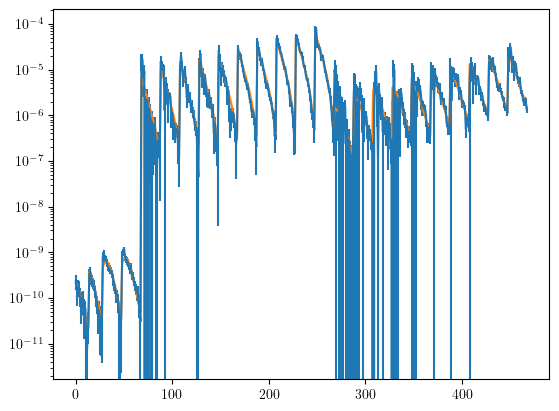

In [16]:
pl.figure()
pl.errorbar(np.arange(len(data_vec)), data_vec, np.sqrt(np.diag(cov_total)))
pl.plot(np.arange(len(mu)), mu)
pl.yscale('log')
# pl.xlim(0, 80)
# pl.ylim(0, 2e-9)
pl.show()



In [17]:
index_gty = []
for js in range(80):
    index_gty.append([js%20 ,js//20])
index_gty = jnp.array(index_gty)
len_ind_gty = len(index_gty)
def get_gty_from_index(index):
    index_val = index_gty[index]
    return get_corrfunc_BCMP_test.gty_out_mat[index_val[0], index_val[1]]

gty_all = vmap(get_gty_from_index)(np.arange(80))
xip_all = vmap(get_xip_from_index)(np.arange(200))
xim_all = vmap(get_xim_from_index)(np.arange(200))

save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV/')
# df_measure = pk.load(open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/DESxACT_gty_xip_xim_DV_ilc_SZ_yy.pk', 'rb'))
df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{true_y_file}.pk', 'rb'))
cov_total = df_measure['cov_total']
xi_all = df_measure['xi_all']
theta_all = df_measure['theta_all']
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)

gty_dv = data_vec[:80]
sig_gty_dv = np.sqrt(np.diag(cov_total))[:80]

xip_dv = data_vec[80:280]
sig_xip_dv = np.sqrt(np.diag(cov_total))[80:280]
bin1_xip_dv = df_cs['xip'].data['BIN1']
bin2_xip_dv = df_cs['xip'].data['BIN2']

xim_dv = data_vec[280:]
sig_xim_dv = np.sqrt(np.diag(cov_total))[280:]
bin1_xim_dv = df_cs['xim'].data['BIN1']
bin2_xim_dv = df_cs['xim'].data['BIN2']


# cov_total = cov_total[80:, 80:]
# data_vec = data_vec[80:]



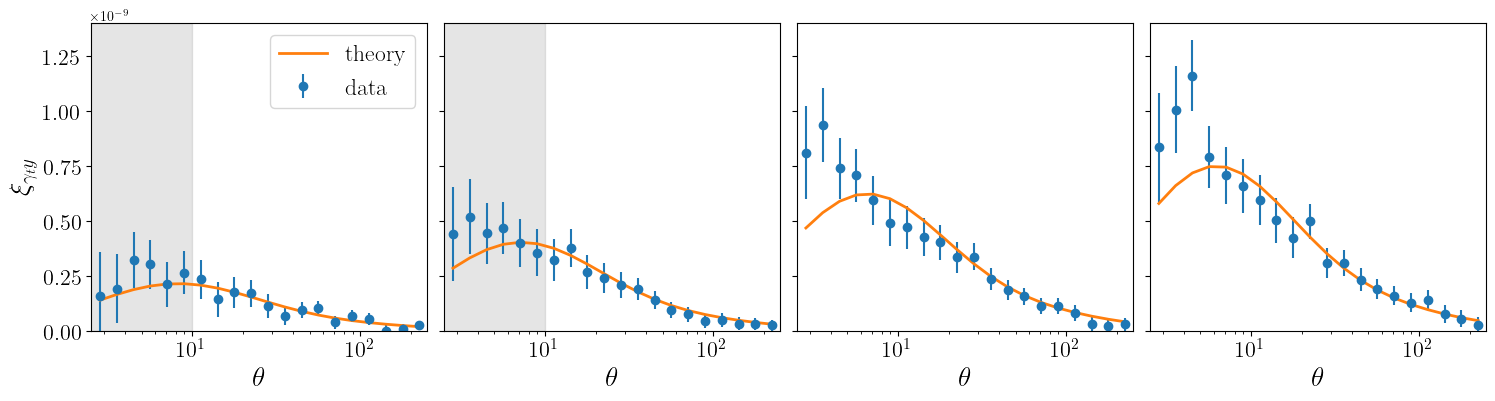

In [18]:
# make a four subplot figure:
fig, axes = pl.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji in range(4):
    ax = axes[ji]
    ax.errorbar(theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label='data', ls='', marker='o')
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_all[ji*20:(ji+1)*20], label='theory', lw=2)
    # ax.set_title(f'gty bin {ji+1}')
    if ji == 0:
        ax.legend(fontsize=17)
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_ylim(0, 1.4e-9)
    ax.set_xlabel(r'$\theta$', fontsize=20)

    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=16)
    ax.set_xlim(2.5, 250)
    if ji == 0:
        ax.set_ylabel(r'$\xi_{\gamma_t y}$', fontsize=20)

    if ji < 2:
        ax.axvspan(0, 10, color='gray', alpha=0.2)
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/gty_dv.png', bbox_inches='tight', dpi=300)
pl.show()



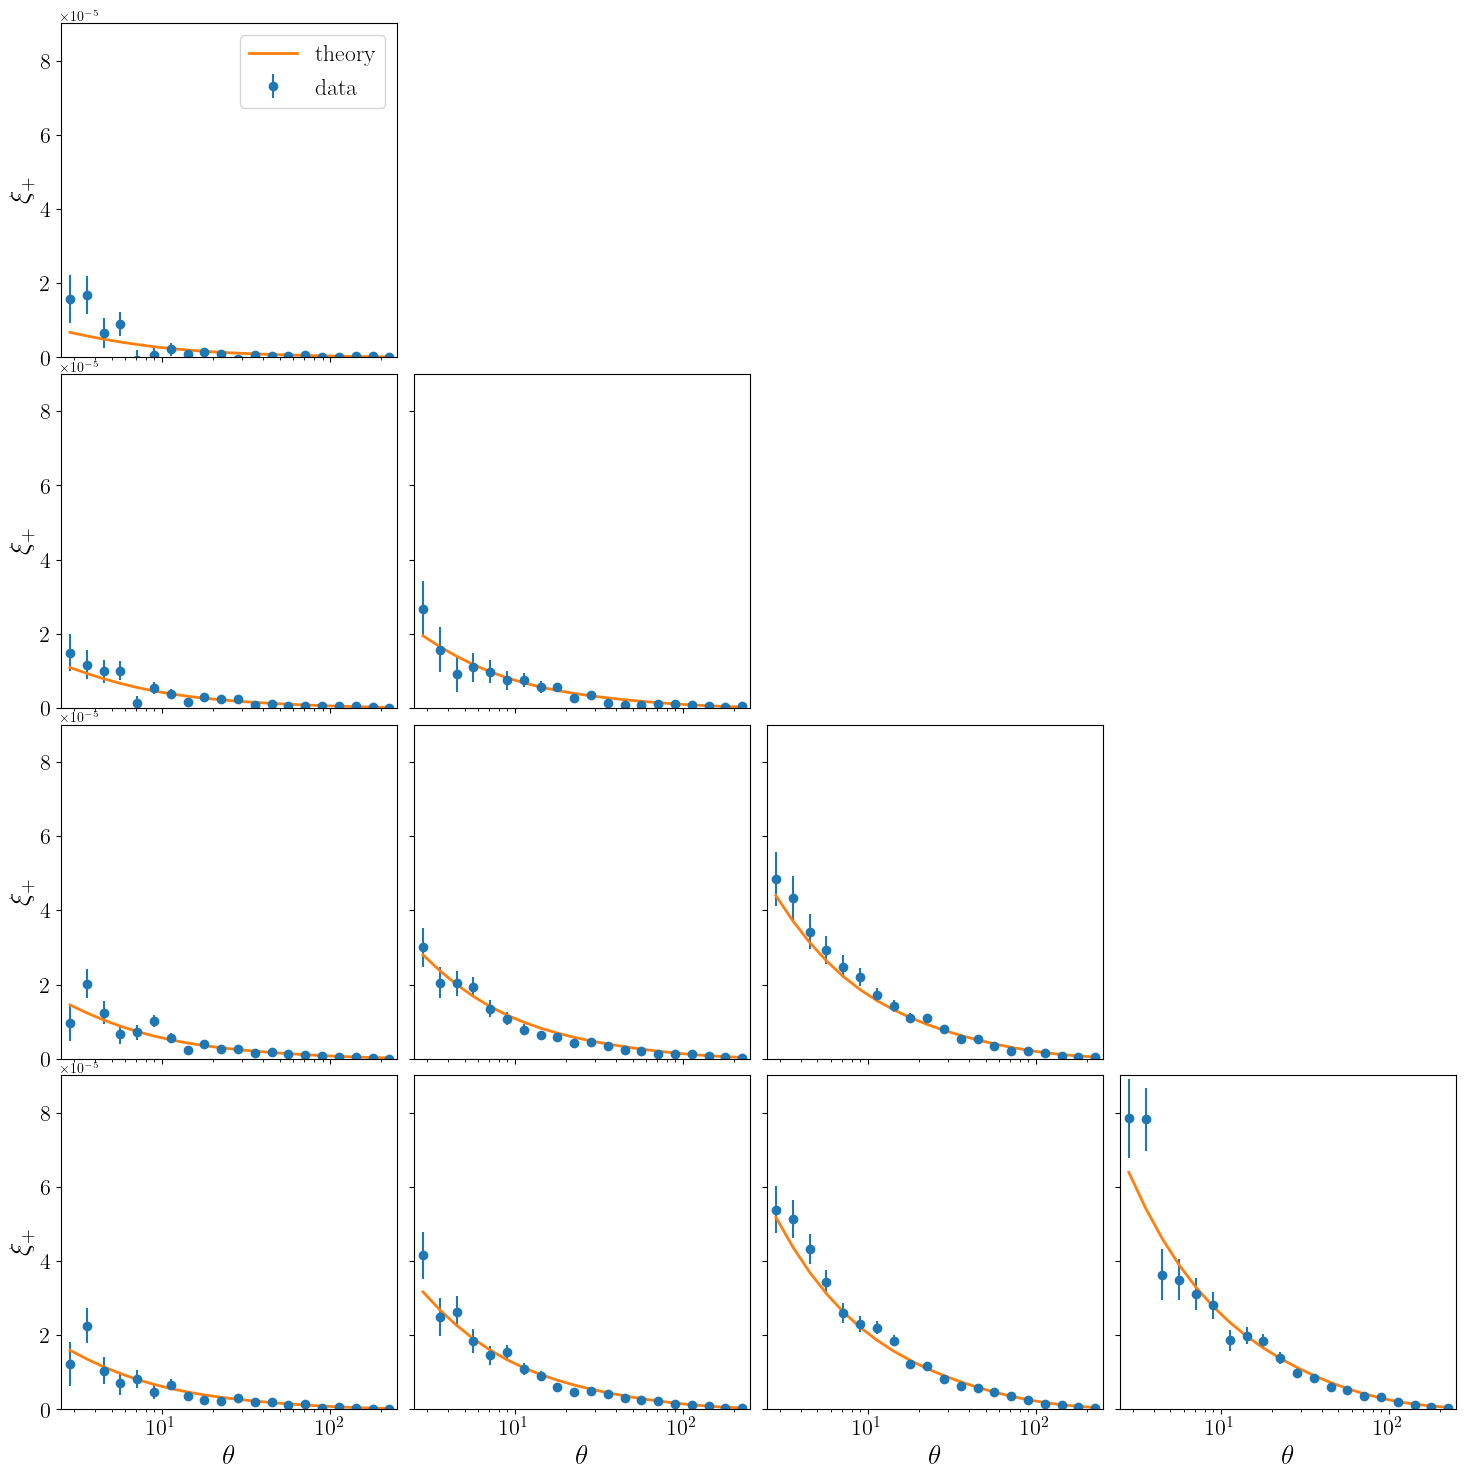

In [19]:
# make a four subplot figure:
theta_xip = theta_all[80:280]
theta_xim = theta_all[280:]
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
            ax.errorbar(theta_xip[indsel], xip_dv[indsel], sig_xip_dv[indsel], label='data', ls='', marker='o')
            ax.plot(theta_xip[indsel], xip_all[indsel], label='theory', lw=2)
            # ax.set_title(f'gty bin {ji+1}')
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0, 9e-5)
            ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$\xi_{+}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
pl.show()


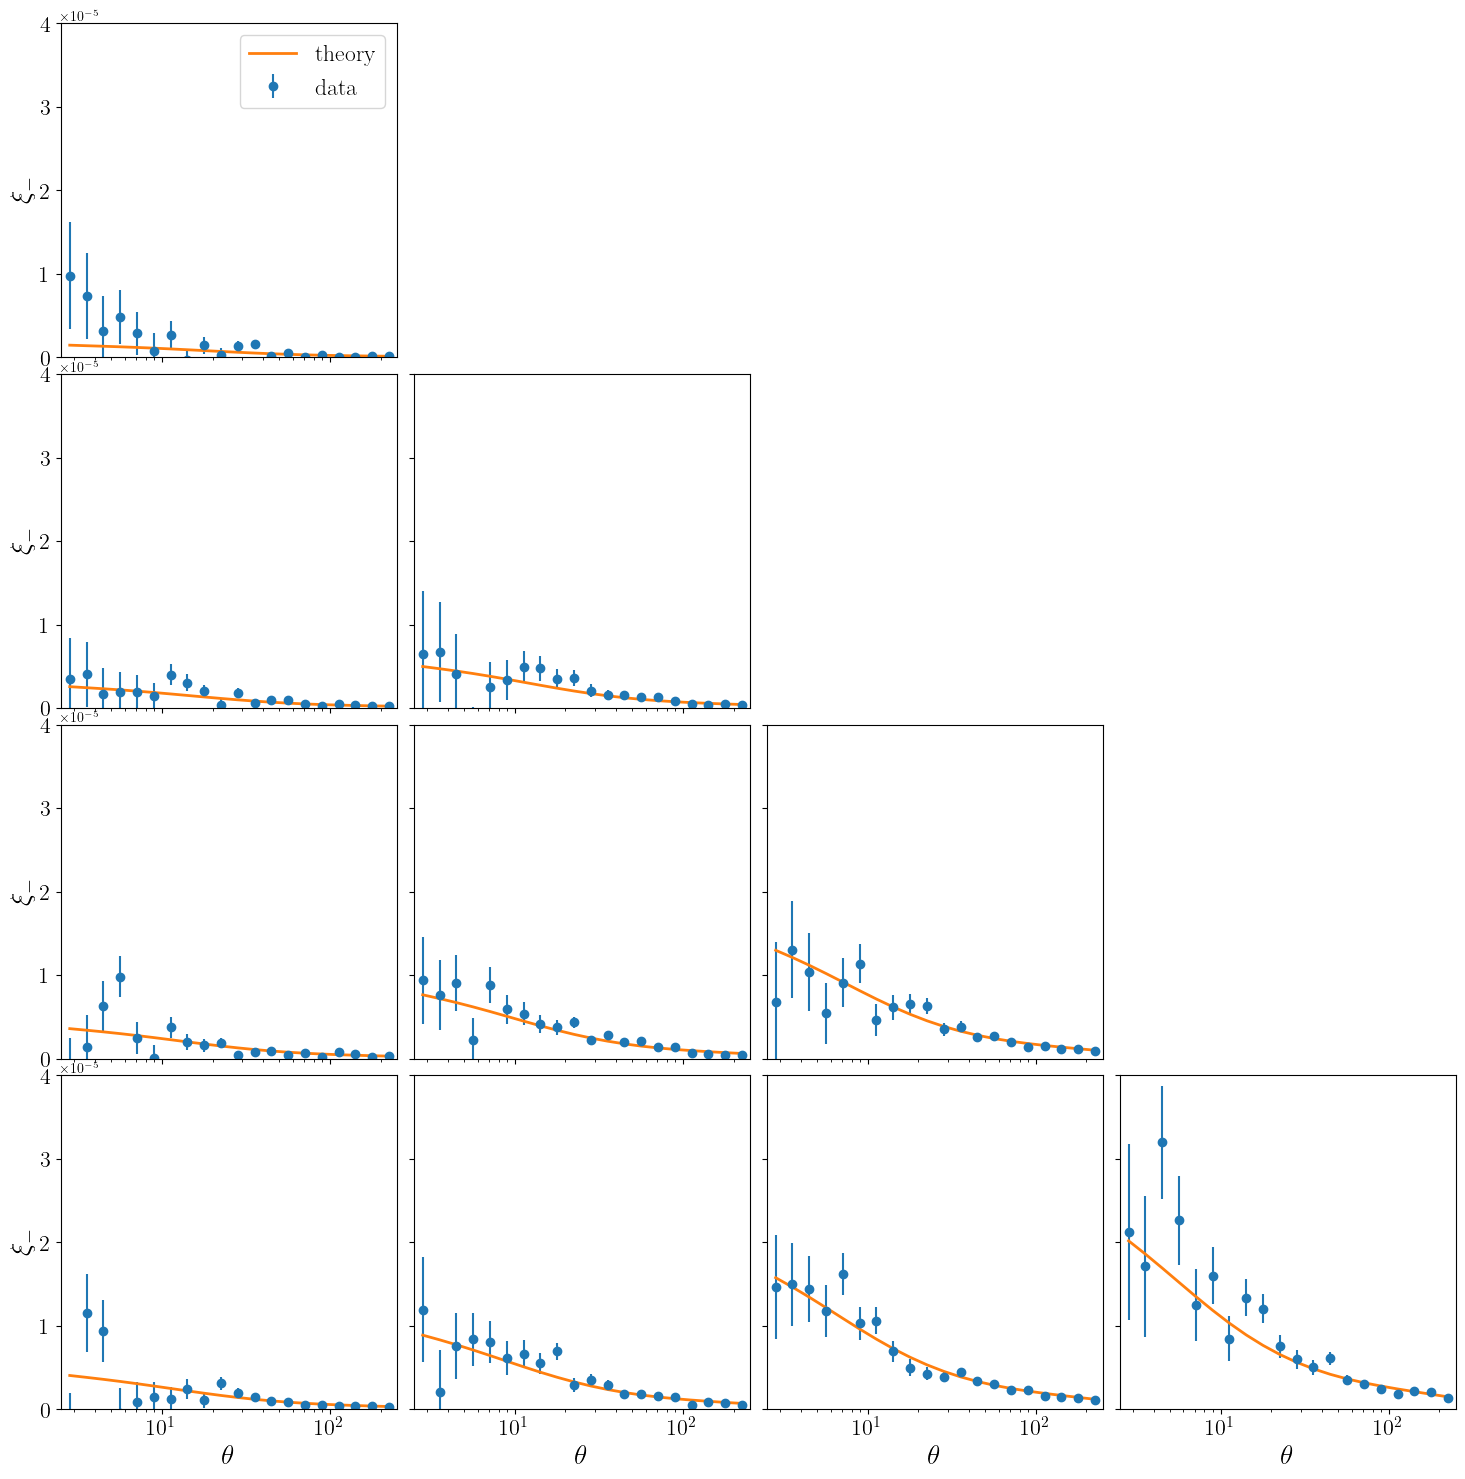

In [20]:
# make a four subplot figure:
theta_xip = theta_all[80:280]
theta_xim = theta_all[280:]
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xim_dv == ji1+1) & (bin2_xim_dv == ji2+1))[0]
            ax.errorbar(theta_xim[indsel], xim_dv[indsel], sig_xim_dv[indsel], label='data', ls='', marker='o')
            ax.plot(theta_xim[indsel], xim_all[indsel], label='theory', lw=2)
            # ax.set_title(f'gty bin {ji+1}')
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0, 4e-5)
            ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$\xi_{-}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# pl.yscale('log')
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xim_dv.png', bbox_inches='tight', dpi=300)
pl.show()




In [7]:
index_gty = []
for js in range(80):
    index_gty.append([js%20 ,js//20])
index_gty = jnp.array(index_gty)
# len_ind_gty = 
print(len(index_gty), len(index_xip), len(index_xim))


80 200 200


In [21]:
import jax 
from tqdm import tqdm
import copy
from get_corr_func import get_corrfunc_BCMP

@jax.jit
def get_mean_cosmo(logp):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    for jp in range(len(cosmo_params_vary_names)):
        sim_params_dict_vary['cosmo'][cosmo_params_vary_names[jp]] = jnp.exp(logp[jp])
    
    get_corrfunc_BCMP_test = get_corrfunc_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, verbose_time=False)

    # def get_gty_from_index(index):
    #     index_val = index_gty[index]
    #     return get_corrfunc_BCMP_test.gty_out_mat[index_val[0], index_val[1]]

    def get_xip_from_index(index):
        index_val = index_xip[index]
        return get_corrfunc_BCMP_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

    def get_xim_from_index(index):
        index_val = index_xim[index]
        return get_corrfunc_BCMP_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

    # gty_val = vmap(get_gty_from_index)(np.arange(80))
    xip_val = vmap(get_xip_from_index)(np.arange(200))
    xim_val = vmap(get_xim_from_index)(np.arange(200))
    # mu = jnp.concatenate([gty_val, xip_val, xim_val])
    mu = jnp.concatenate([xip_val, xim_val])

    # mu = jnp.concatenate([get_corrfunc_BCMP_test.gty_out_mat[:,3], get_corrfunc_BCMP_test.xip_out_mat[:,3,3], get_corrfunc_BCMP_test.xim_out_mat[:,3,3]])

    return jnp.log(mu)




In [22]:

# cosmo_params_vary_names_all = ['Om0', 'Ob0', 'H0', 'ns', 'sigma8']
# cosmo_params_vary_names_all = ['Om0', 'Ob0', 'sigma8']
cosmo_params_vary_names_all = ['Om0', 'sigma8']

cosmo_params_fid_all = np.zeros(len(cosmo_params_vary_names_all))
for jp in range(len(cosmo_params_vary_names_all)):
    cosmo_params_fid_all[jp] = sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]

# dmu_cosmo_all = np.zeros((480, len(cosmo_params_vary_names_all)))
dmu_cosmo_all = np.zeros((400, len(cosmo_params_vary_names_all)))
for jp in tqdm(range(len(cosmo_params_vary_names_all))):
    cosmo_params_vary_names = [cosmo_params_vary_names_all[jp]]
    params_fid = jnp.log(jnp.array([sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]]))

    jac_mean = jax.jit(jax.jacfwd(get_mean_cosmo))
    dmu_cosmo = jac_mean(params_fid)
    dmu_cosmo_all[:, jp] = dmu_cosmo[:,0]







  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [01:30<00:00, 45.39s/it]


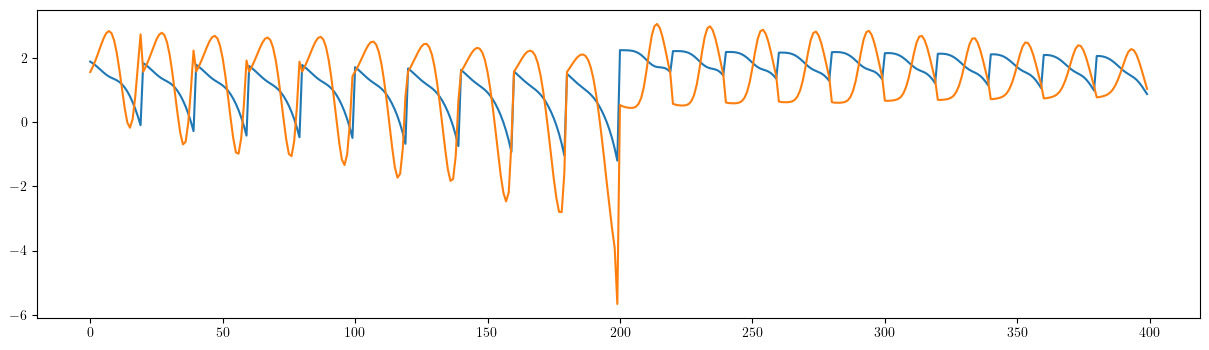

In [23]:
pl.figure(figsize=(15,4))
# pl.errorbar(np.arange(len(data_vec)), data_vec, np.sqrt(np.diag(cov_total)))
pl.plot(np.arange(len(dmu_cosmo_all[:,0])), dmu_cosmo_all[:,0])
pl.plot(np.arange(len(dmu_cosmo_all[:,1])), dmu_cosmo_all[:,1])
# pl.yscale('log')
# pl.xlim(0, 80)
# pl.ylim(0, 2e-9)
pl.show()



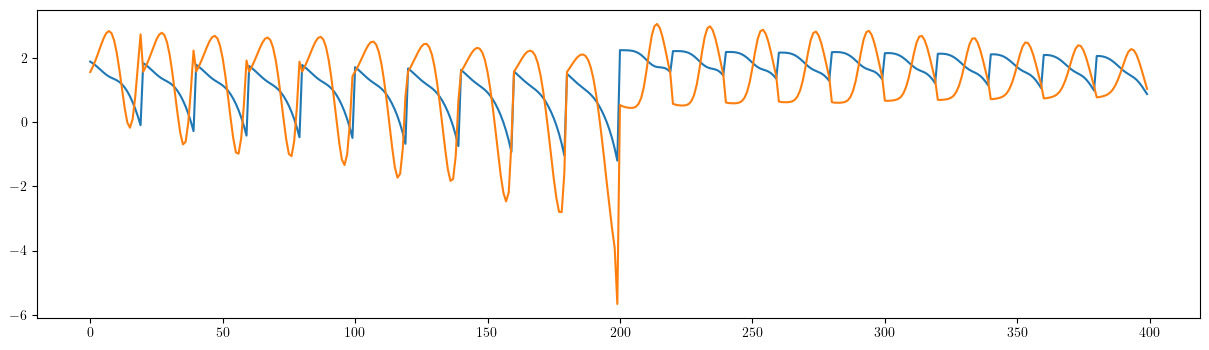

In [19]:
pl.figure(figsize=(15,4))
# pl.errorbar(np.arange(len(data_vec)), data_vec, np.sqrt(np.diag(cov_total)))
pl.plot(np.arange(len(dmu_cosmo_all[:,0])), dmu_cosmo_all[:,0])
pl.plot(np.arange(len(dmu_cosmo_all[:,1])), dmu_cosmo_all[:,1])
# pl.yscale('log')
# pl.xlim(0, 80)
# pl.ylim(0, 2e-9)
pl.show()



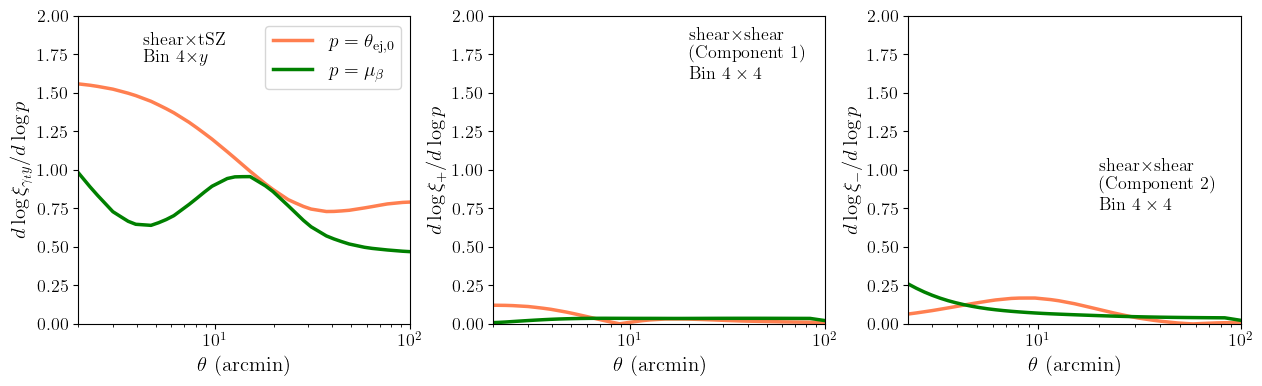

In [2]:
import matplotlib
%matplotlib inline


In [5]:
from getdist import MCSamples
def get_param_names(filename):
    with open(filename,"r") as fi:
        param_names = np.array((fi.readline()[1:].split()))
    return param_names

def replace_fancy(names, fancy_dic):
    output_names = []
    ind_data = []
    for ii in range(len(names)):
        if (names[ii] in fancy_dic):
            output_names.append(fancy_dic[names[ii]])
            ind_data.append(ii)
    return np.array(output_names), np.array(ind_data)
# fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','cosmological_parameters--s8':r'$S_8$'} 
filename = '/projects/bdne/spandey3/GODMAX/results/ACTxDES/chain_1x2pt_lcdm_SR_maglim.txt'
data = np.loadtxt(filename)
weights = np.loadtxt(filename)[:,-1]
param_names = get_param_names(filename)
# 
fancy_dictionary = {'cosmological_parameters--omega_m':r'$\Omega_m$','COSMOLOGICAL_PARAMETERS--SIGMA_8':r'$\sigma_8$'} 
param_names_fancy, selection = replace_fancy(np.array(param_names), fancy_dictionary)

data_y3kp = data[:,selection]
param_names = param_names[selection]
param_names_fancy = param_names_fancy

data_Om = data_y3kp[:,0]
data_sigma8 = data_y3kp[:,1]
data_S8 = data_sigma8 * np.sqrt(data_Om/0.3)
data = np.column_stack((data_Om, data_sigma8, data_S8))

# all_data.append(data)

# samples_y3kp = MCSamples(samples=data_y3kp,\
#                     weights=weights, \
#                     names = ['Om0','sigma8'], labels = [r'$\Omega_m$', r'$\sigma_8$'])

samples_y3kp = MCSamples(samples=data,\
                    weights=weights, \
                    names = ['Om0','sigma8','S8'], labels = [r'$\Omega_m$', r'$\sigma_8$', r'$S_8$'])




Removed no burn in


Removed no burn in
Removed no burn in
Removed no burn in


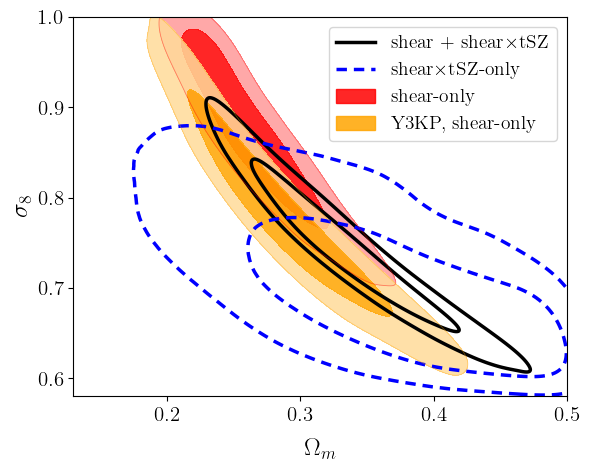

In [8]:

import getdist
from getdist import plots, MCSamples

ldir = '/projects/bdne/spandey3/GODMAX/results/ACTxDES/'
# df = pk.load(open(ldir + 'samps_probes_xipm4_response_response.pkl','rb'))
df = pk.load(open(ldir + 'samps_probes_xipm_npfNov_response_response.pkl','rb'))
samps = df['samps']
names = df['names']
labels = df['labels']
samples_xipm = MCSamples(samples=samps,names = names, labels = labels)

# df = pk.load(open(ldir + 'samps_probes_gty_response_response.pkl','rb'))
df = pk.load(open(ldir + 'samps_probes_gty_npfNov_response_response.pkl','rb'))
samps = df['samps']
names = df['names']
labels = df['labels']
samples_gty = MCSamples(samples=samps,names = names, labels = labels)

# df = pk.load(open(ldir + 'samps_probes_all_response_response.pkl','rb'))
df = pk.load(open(ldir + 'samps_probes_all_npfNov_response_response.pkl','rb'))
samps = df['samps']
names = df['names']
labels = df['labels']
samples_all = MCSamples(samples=samps,names = names, labels = labels)


g = plots.getSinglePlotter(width_inch=6, ratio=0.8)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':2.5,'color':'black'},{'lw':2.5,'color':'blue'},{'lw':0.1,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}
# g.plot_2d([samples_all, samples_gty, samples_xipm, samples_y3kp], 'Om0', 'sigma8', line_args=line_args, 
#             contour_lws=[1.5], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
#             ls=['-','--','','',''] ,
#             lims=[0.13, 0.5, 0.58, 1.0])  

g.plot_2d([samples_all, samples_gty, samples_xipm, samples_y3kp], 'Om0', 'sigma8', line_args=line_args, 
            contour_lws=[1.5], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''] ,
            lims=[0.13, 0.5, 0.58, 1.0])  


g.add_legend([r'shear + shear$\times$tSZ',r'shear$\times$tSZ-only', r'shear-only',  r'Y3KP, shear-only'], legend_loc='upper right', fontsize=14)
# g.export(ldir + 'contour_Om0_sigma8_response_response.png', dpi=300)
import matplotlib
%matplotlib inline
pl.show()


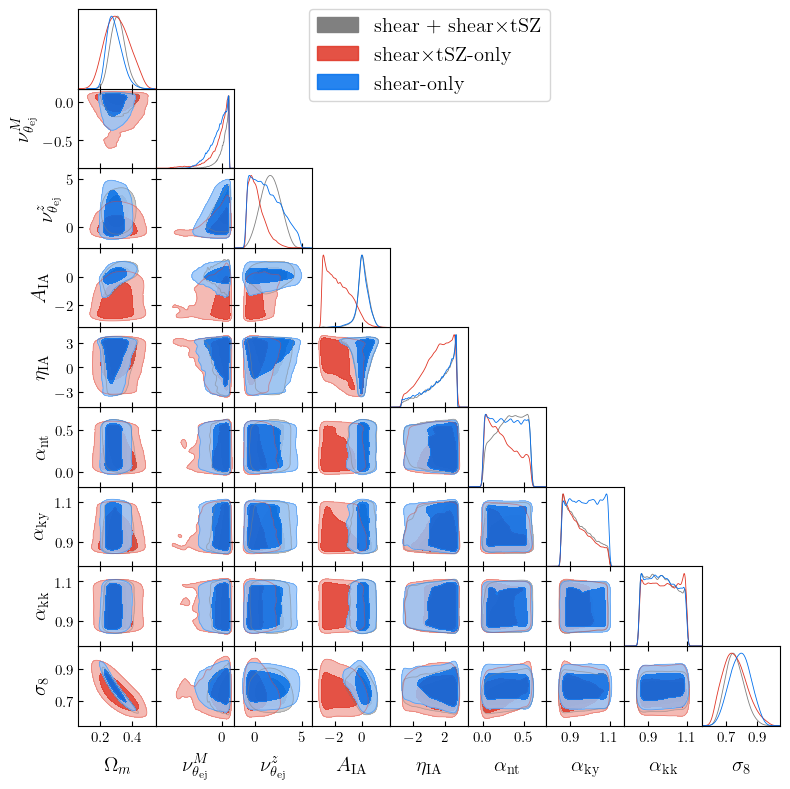

In [116]:
params = ['Om0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
g = plots.get_subplot_plotter(width_inch=8)
g.settings.axes_fontsize   = 16
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 2.0
legend_labels = [r'shear + shear$\times$tSZ',r'shear$\times$tSZ-only', r'shear-only']
g.triangle_plot([samples_all, samples_gty, samples_xipm], params,legend_labels = legend_labels, filled=True)
# g.add_legend(, legend_loc='upper right', fontsize=14)
g.export('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/contour_all_params.png', dpi=300)




In [44]:
h = sim_params_dict['cosmo']['H0'] / 100.0
Ob = sim_params_dict['cosmo']['Ob0']
Om = sim_params_dict['cosmo']['Om0']
import astropy.units as u
from astropy import constants as const
import jax_cosmo.background as bkgrd
import scipy.integrate as integrate
from setup_power_spectra import setup_power_BCMP
sigmat = const.sigma_T
m_e = const.m_e
c = const.c
coeff = sigmat / (m_e * (c ** 2))
oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value






In [45]:
import copy
from tqdm import tqdm
from get_BCMP_profile import BCM_18_wP

BCMP_test = BCM_18_wP(sim_params_dict, halo_params_dict, verbose_time=False)



In [46]:
BCMP_test.Pe_mat_physical.shape


(32, 22, 24)

In [47]:
from scipy.interpolate import interp1d
import jax_cosmo.background as bkgrd
z_array = BCMP_test.z_array
scale_fac_a_array = 1.0 / (1.0 + z_array)
indz = 0
Ez = np.sqrt(bkgrd.growth_factor(BCMP_test.cosmo_jax, scale_fac_a_array))[indz]
# M200_noh = M_array[indM]/h
h70 = h/0.7
M_array = BCMP_test.M_array
Y_model_all = np.zeros(len(M_array))
Y_ss_all = np.zeros(len(M_array))
for jM in range(len(M_array)):
    Mj = M_array[jM]
    M200_noh = Mj/h
    Y_ss = 97.6 * (1/h70) * (Ez**(2/3.)) * (M200_noh/(1e15/h70))**(5/3.) * (Ob/0.043) * (0.25/Om)

    # r200_jM = BCMP_test.r200c_mat[jM, indz]
    r200_jM = BCMP_test.r500c_mat[jM, indz]    
    r_array_jM = np.logspace(-2, np.log10(r200_jM), 100)
    Pe_jz_jM = BCMP_test.Pe_mat_physical[:, indz, jM]
    interpPe = interp1d(np.log(BCMP_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    Y_jM = np.trapz(4 * np.pi * r_array_jM**2 * Pe_jM, r_array_jM)

    Y_model_all[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
    Y_ss_all[jM] = Y_ss


/tmp/ipykernel_129276/2450431900.py:21: RuntimeWarning: divide by zero encountered in log
  interpPe = interp1d(np.log(BCMP_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')


In [26]:
# r200_jM
# BCMP_test.r200c_mat[:,0]
# r_array_jM
# Pe_jM
# h

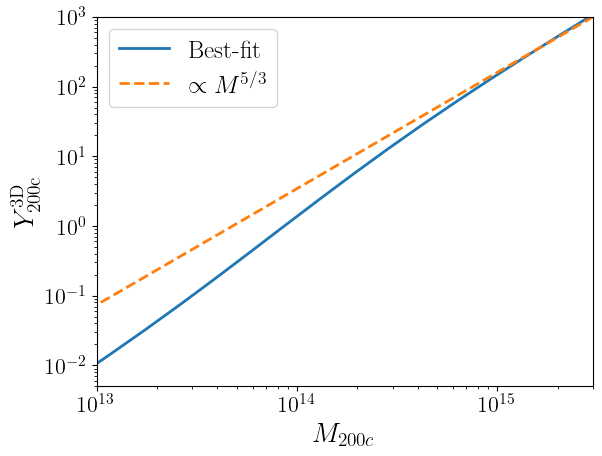

In [48]:
pl.figure()
pl.plot(M_array, Y_model_all, label='Best-fit', lw=2.0)
pl.plot(M_array, 1.6e-23 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 3e15)
pl.ylim(5e-3, 1e3)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
pl.show()




In [34]:
import copy
from tqdm import tqdm
# from get_corr_func_jit import get_corrfunc_BCMP
from setup_power_spectra import setup_power_BCMP
# sim_params_dict['nu_theta_ej_M'] = -0.1
setup_power_test = setup_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, verbose_time=False)




In [38]:
Pmm_dmb_1h = setup_power_test.Pmm_dmb_1h_mat
# Pmm_dmb_2h = setup_power_test.Pmm_dmb_2h_mat
Pmm_dmb_tot = setup_power_test.Pmm_dmb_tot_mat

Pmm_nfw_1h = setup_power_test.Pmm_nfw_1h_mat
# Pmm_nfw_2h = setup_power_test.Pmm_nfw_2h_mat
Pmm_nfw_tot = setup_power_test.Pmm_nfw_tot_mat

Pmm_hf = setup_power_test.phfit_kz_mat


(0.6, 1.2)

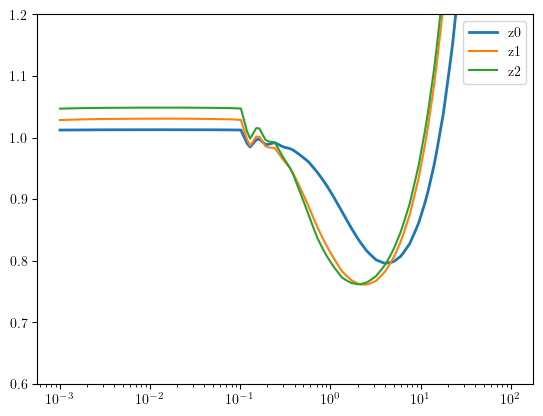

In [39]:
Pmm_sup_mat = Pmm_dmb_tot/Pmm_nfw_tot
pl.figure()
pl.plot(setup_power_test.k, Pmm_sup_mat[:, 0], label='z0', lw=2.)
pl.plot(setup_power_test.k, Pmm_sup_mat[:, 4], label='z1')
pl.plot(setup_power_test.k, Pmm_sup_mat[:, 8], label='z2')
pl.legend()
# pl.plot(setup_power_test.k, Pmm_sup_mat[:, 12], label='1h dmb')
pl.xscale('log')
pl.ylim(0.6, 1.2)




(0.7, 1.3)

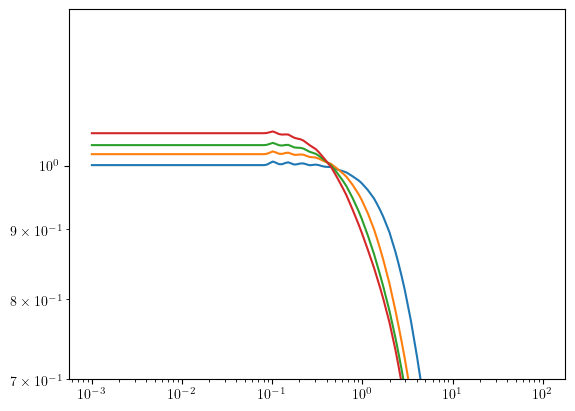

In [486]:
ratio = setup_power_test.uk_dmb
# ratio = setup_power_test.uk_nfw
# ratio.shape
jM = 5
pl.figure()
pl.plot(setup_power_test.k, ratio[:, 0,jM], label='1h dmb')
pl.plot(setup_power_test.k, ratio[:, 4,jM], label='1h dmb')
pl.plot(setup_power_test.k, ratio[:, 8,jM], label='1h dmb')
pl.plot(setup_power_test.k, ratio[:, 12,jM], label='1h dmb')
pl.xscale('log')
pl.yscale('log')
pl.ylim(0.7, 1.3)

